REGION DASHBOARD
Total Sales      : 233,650,194.43
Total Orders     : 201,716
Total Quantity   : 862,411
Average Order    : 1,158.31


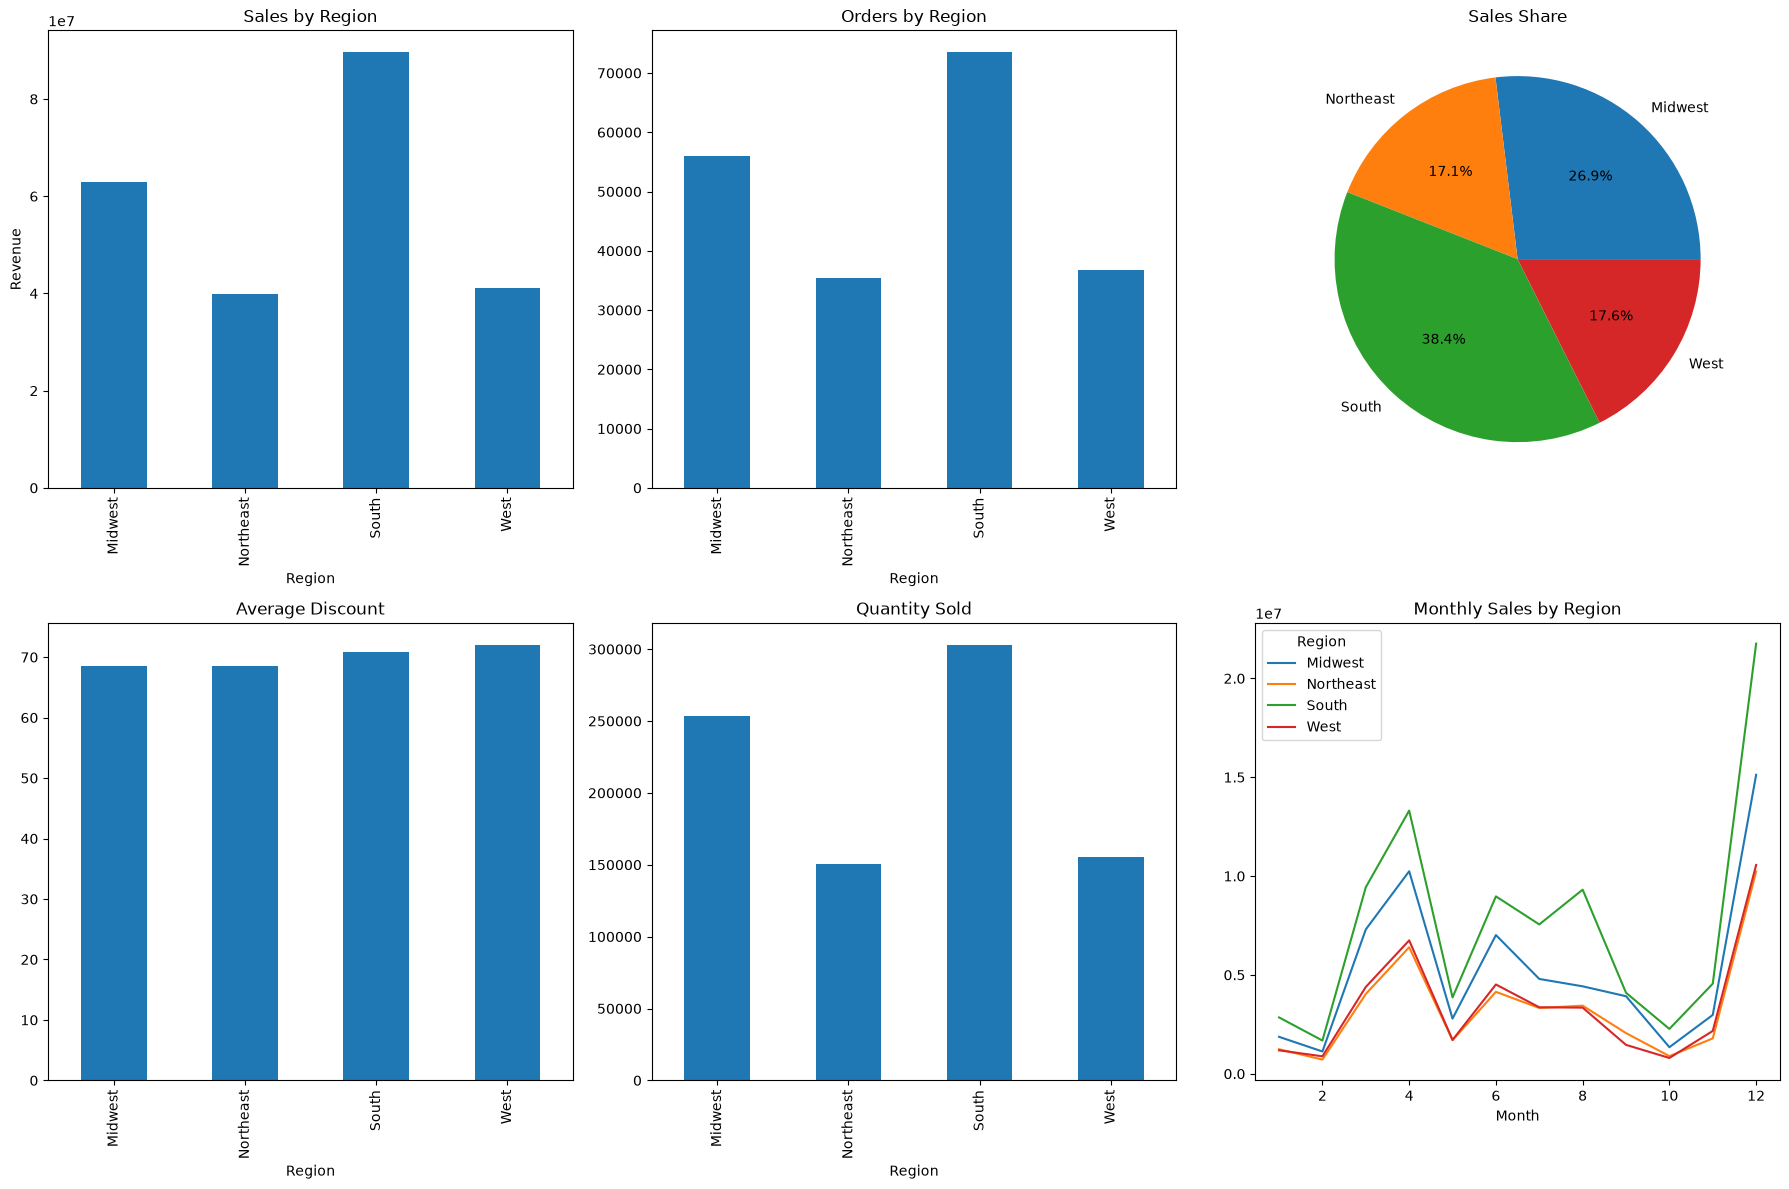

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Đọc dữ liệu
# ==============================

df = pd.read_csv(
    r"D:\PRO_du án tốt nghiệp\data\raw\sales_06_FY2020-21.csv",
    low_memory=False
)

# ==============================
# Làm sạch dữ liệu
# ==============================

df["total"] = pd.to_numeric(df["total"], errors="coerce")
df["qty_ordered"] = pd.to_numeric(df["qty_ordered"], errors="coerce")
df["discount_amount"] = pd.to_numeric(df["discount_amount"], errors="coerce")

df["order_date"] = pd.to_datetime(df["order_date"])

df = df.dropna(subset=["Region"])

# ==============================
# KPI
# ==============================

total_sales = df["total"].sum()

total_orders = df["order_id"].nunique()

total_quantity = df["qty_ordered"].sum()

avg_order = df.groupby("order_id")["total"].sum().mean()

print("="*50)
print("REGION DASHBOARD")
print("="*50)

print(f"Total Sales      : {total_sales:,.2f}")

print(f"Total Orders     : {total_orders:,}")

print(f"Total Quantity   : {total_quantity:,.0f}")

print(f"Average Order    : {avg_order:,.2f}")

# ==================================================
# Tạo Dashboard
# ==================================================

fig = plt.figure(figsize=(18,12))

# --------------------------------------------------
# 1. Sales theo Region
# --------------------------------------------------

ax1 = plt.subplot(2,3,1)

sales_region = df.groupby("Region")["total"].sum()

sales_region.plot(kind="bar", ax=ax1)

ax1.set_title("Sales by Region")

ax1.set_ylabel("Revenue")

# --------------------------------------------------
# 2. Orders theo Region
# --------------------------------------------------

ax2 = plt.subplot(2,3,2)

orders_region = df.groupby("Region")["order_id"].nunique()

orders_region.plot(kind="bar", ax=ax2)

ax2.set_title("Orders by Region")

# --------------------------------------------------
# 3. Pie Sales
# --------------------------------------------------

ax3 = plt.subplot(2,3,3)

sales_region.plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax3
)

ax3.set_ylabel("")

ax3.set_title("Sales Share")

# --------------------------------------------------
# 4. Discount
# --------------------------------------------------

ax4 = plt.subplot(2,3,4)

discount = df.groupby("Region")["discount_amount"].mean()

discount.plot(kind="bar", ax=ax4)

ax4.set_title("Average Discount")

# --------------------------------------------------
# 5. Quantity
# --------------------------------------------------

ax5 = plt.subplot(2,3,5)

qty = df.groupby("Region")["qty_ordered"].sum()

qty.plot(kind="bar", ax=ax5)

ax5.set_title("Quantity Sold")

# --------------------------------------------------
# 6. Monthly Sales
# --------------------------------------------------

ax6 = plt.subplot(2,3,6)

monthly = df.groupby(
    [df["order_date"].dt.month, "Region"]
)["total"].sum().unstack()

monthly.plot(ax=ax6)

ax6.set_title("Monthly Sales by Region")

ax6.set_xlabel("Month")

plt.tight_layout()

plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Đọc dữ liệu
# ==============================

df = pd.read_csv(
    r"D:\PRO_du án tốt nghiệp\data\raw\sales_06_FY2020-21.csv",
    low_memory=False
)

# ==============================
# Làm sạch dữ liệu
# ==============================

df["total"] = pd.to_numeric(df["total"], errors="coerce")
df["qty_ordered"] = pd.to_numeric(df["qty_ordered"], errors="coerce")
df["discount_amount"] = pd.to_numeric(df["discount_amount"], errors="coerce")

df["order_date"] = pd.to_datetime(df["order_date"])

df = df.dropna(subset=["Region"])

## Sales by Region 

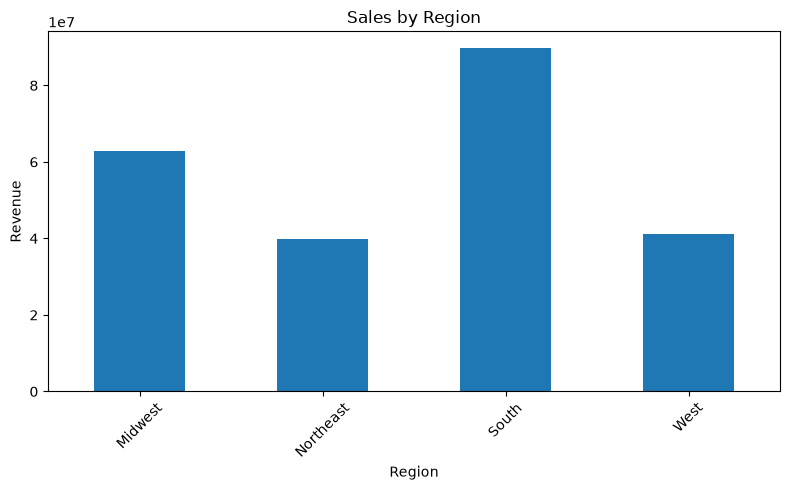

In [3]:

sales_region = df.groupby("Region")["total"].sum()

plt.figure(figsize=(8,5))

sales_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Orders by Region

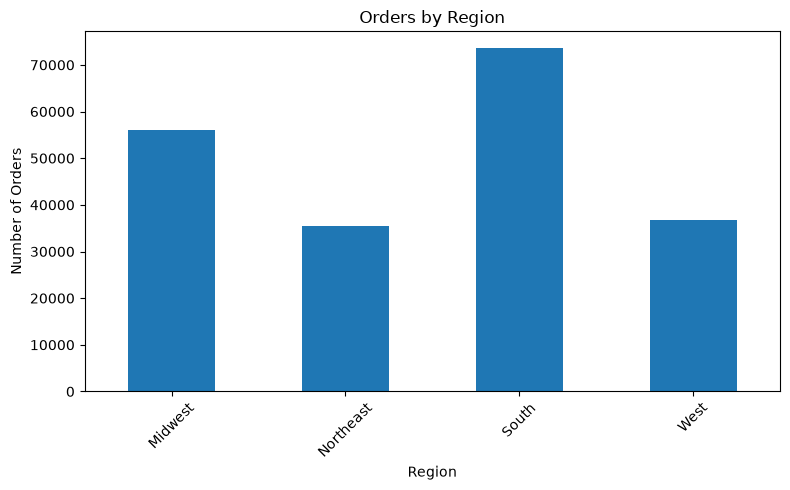

In [4]:
orders_region = df.groupby("Region")["order_id"].nunique()

plt.figure(figsize=(8,5))

orders_region.plot(kind="bar")

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Sales Share (Pie Chart)

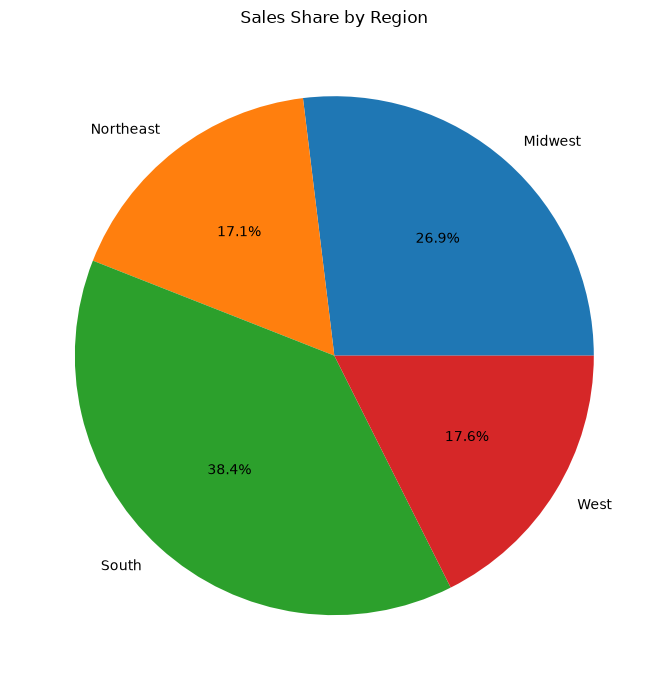

In [5]:
sales_region = df.groupby("Region")["total"].sum()

plt.figure(figsize=(7,7))

sales_region.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Share by Region")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Average Discount by Region

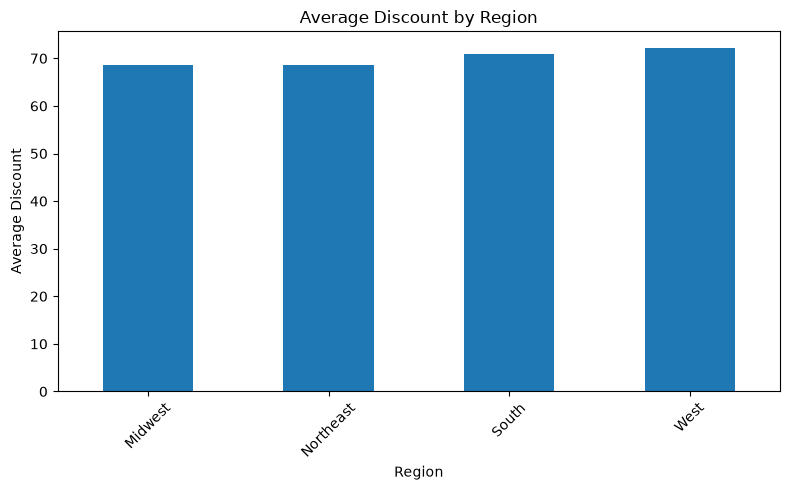

In [6]:
discount = df.groupby("Region")["discount_amount"].mean()

plt.figure(figsize=(8,5))

discount.plot(kind="bar")

plt.title("Average Discount by Region")
plt.xlabel("Region")
plt.ylabel("Average Discount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Quantity Sold by Region


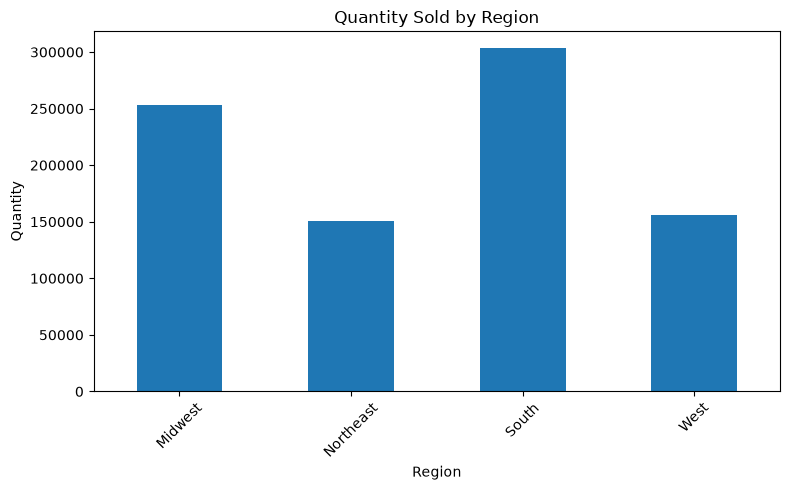

In [7]:
qty = df.groupby("Region")["qty_ordered"].sum()

plt.figure(figsize=(8,5))

qty.plot(kind="bar")

plt.title("Quantity Sold by Region")
plt.xlabel("Region")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Monthly Sales by Region

<Figure size 1000x600 with 0 Axes>

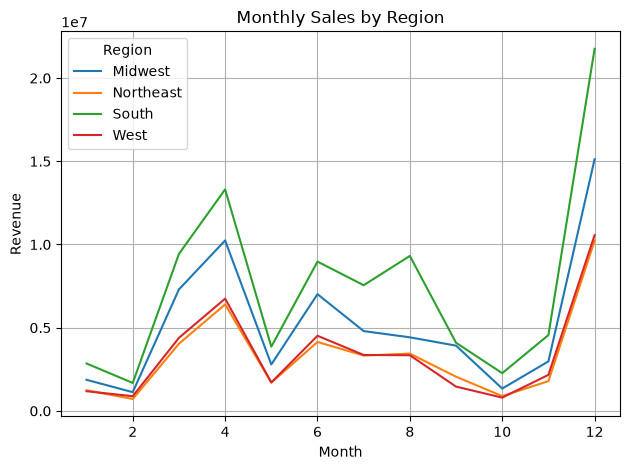

In [8]:
monthly = (
    df.groupby([df["order_date"].dt.month, "Region"])["total"]
      .sum()
      .unstack()
)

plt.figure(figsize=(10,6))

monthly.plot()

plt.title("Monthly Sales by Region")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()
plt.show()